In [ ]:
!pip install keras-nlp
!pip install tensorflow


--- Distribuição das Classes ---
Label
1    26400
0    26400
Name: count, dtype: int64
Label
1    50.0
0    50.0
Name: proportion, dtype: float64


/tmp/ipykernel_447/3677533111.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='viridis')


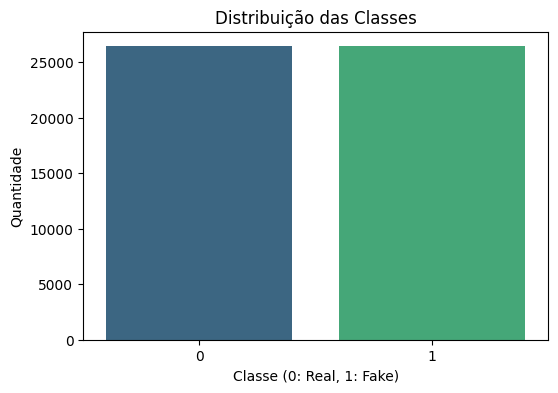


Treinando e Avaliando: SGD Classifier

Acurácia:  0.9454
Precisão:  0.9558
Revocação: 0.9340
F1-Score:  0.9448


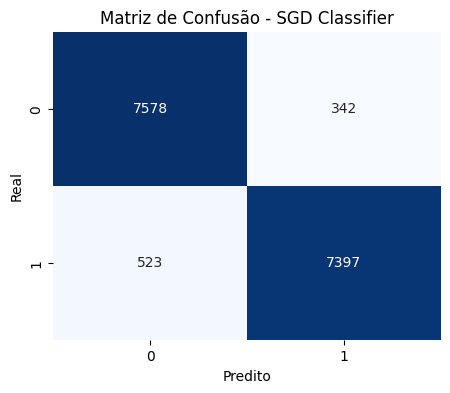


Treinando e Avaliando: Random Forest Classifier

Acurácia:  0.9328
Precisão:  0.9484
Revocação: 0.9153
F1-Score:  0.9316


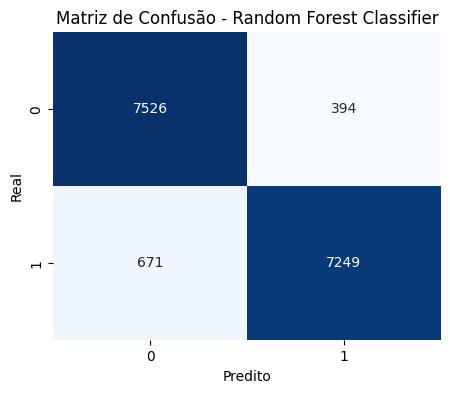

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Carregamento dos Dados

df = pd.read_csv('/content/sample_data/fakerecogna2.csv', encoding='latin-1')


# Análise Exploratória de Dados

print("\n--- Distribuição das Classes ---")
print(df['Label'].value_counts())
print(df['Label'].value_counts(normalize=True) * 100)


# Gráfico da distribuição das classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label', palette='viridis')
plt.title('Distribuição das Classes')
plt.xlabel('Classe (0: Real, 1: Fake)')
plt.ylabel('Quantidade')
plt.show()


# Divisão do Dataset
features = df['Noticia'].astype(str)
labels = df['Label']


# Divisão treino-teste
train_features, val_features, train_labels, val_labels = train_test_split(
    features, labels, test_size=0.3, random_state=42, stratify=labels
)


# Pré-processamento
# (TF-IDF) Mede a frequência com que um termo aparece em relação ao conjunto total
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(train_features)
X_val_vec = vectorizer.transform(val_features)


# Treinamento e Avaliação

models = {
    "SGD Classifier": SGDClassifier(random_state=42, max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\nTreinando e Avaliando: {name}\n")

    # Treinamento
    model.fit(X_train_vec, train_labels)

    # Predição
    y_pred = model.predict(X_val_vec)

    # Métricas
    acc = accuracy_score(val_labels, y_pred)
    prec = precision_score(val_labels, y_pred, zero_division=0)
    rec = recall_score(val_labels, y_pred, zero_division=0)
    f1 = f1_score(val_labels, y_pred, zero_division=0)
    cm = confusion_matrix(val_labels, y_pred)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

    print(f"Acurácia:  {acc:.4f}")
    print(f"Precisão:  {prec:.4f}")
    print(f"Revocação: {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Matriz de Confusão
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {name}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()